### This notebook estimates the Effective Degrees of Freedom in L2reg and NNLS global models to compare simplicity/complexity of them

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nb
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.summarize as ccs

/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


#### Load global NNLS without L2 regularization of all datasets

In [17]:
train_ds_list = gl.get_ldo_names()
EDOF_list_1 = []
for train_ds in train_ds_list:
    NNLS_mo, _ = ccs.get_model(train_ds, 'Icosahedron1002', 'NNLS', 'global', cerebellum_atlas="MNISymC3")
    # count number of entries > 1e-10 in each column of coef_
    nonzero_counts = (NNLS_mo.coef_.T > 1e-10).sum(axis=0)
    EDOF_list_1.append(nonzero_counts.mean())
print(f'Average EDOF for NNLS: {np.mean(EDOF_list_1):.2f} ± {np.std(EDOF_list_1):.2f} (mean ± std)')

Average EDOF for NNLS: 27.85 ± 0.97 (mean ± std)


#### Have to load X for L2reg

In [18]:
train_ds_list = gl.get_ldo_names()
la_list = [2, 2, 4, 2, 2, 4, None, 2, 2]
EDOF_list_2 = []
for train_ds, la in zip(train_ds_list, la_list):
    alpha = np.exp(la) if la is not None else 0
    XX = nb.load(f'{gl.conn_dir}/maps/{train_ds}_data_cortex.pscalar.nii').get_fdata()
    XX_T = XX.T
    S = XX @ np.linalg.inv(XX_T @ XX + alpha * np.identity(XX.shape[1])) @ XX_T
    EDOF_list_2.append(np.trace(S))
print(f'EDOF for L2reg: {np.mean(EDOF_list_2):.2f} ± {np.std(EDOF_list_2):.2f} (mean ± std)')

EDOF for L2reg: 173.25 ± 339.57 (mean ± std)


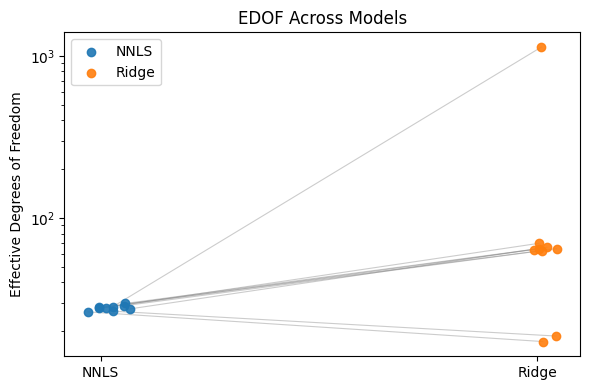

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))

n = len(EDOF_list_1)
rng = np.random.RandomState(0)
jitter = 0.03
x1 = np.zeros(n) + rng.normal(scale=jitter, size=n)
x2 = np.ones(n) + rng.normal(scale=jitter, size=n)

# draw connecting lines for each pair
for i in range(n):
    ax.plot([x1[i], x2[i]],
            [EDOF_list_1[i], EDOF_list_2[i]],
            color='gray', alpha=0.4, linewidth=0.8, zorder=0)

# scatter points (on top of lines)
ax.scatter(x1, EDOF_list_1, color='C0', label='NNLS', alpha=0.9, zorder=2)
ax.scatter(x2, EDOF_list_2, color='C1', label='Ridge', alpha=0.9, zorder=2)

ax.set_xticks([0, 1])
ax.set_xticklabels(['NNLS', 'Ridge'])
ax.set_ylabel('Effective Degrees of Freedom')
ax.set_yscale('log')
ax.set_title('EDOF Across Models')
ax.legend()
plt.tight_layout()
plt.show()
